In [1]:
import pandas as pd
import xarray as xr
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/AGeneratefulldf/DIff_GEV_station_variable_statistics.csv")

In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. START FROM stats_df
# --------------------------------------------------

# Ensure we are working on a copy
df = stats_df.copy()

# --------------------------------------------------
# 2. SELECT NUMERIC VARIABLES ONLY
#    (PCA is ONLY for continuous variables)
# --------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number])

# Optional: drop identifiers if they slipped in
# (station is numeric but should not be in PCA)
#if "station" in numeric_df.columns:
#    numeric_df = numeric_df.drop(columns=["station"])


In [3]:
numeric_df 

,station,u10_mean,u10_std,u10_q95,u10_q99,v10_mean,v10_std,v10_q95,v10_q99,d2m_mean,...,bay_radius_used_deg,coastal_vs_bay_diff_deg,coastal_normal1_deg,coastal_normal2_deg,wind_vs_coastal_normal_diff_deg,wind_more_coastalshore_deg,bay_normal1_deg,bay_normal2_deg,wind_vs_bay_normal_diff_deg,wind_more_bayshore_deg
0,1,5.444261,6.467723,15.987160,18.885735,6.264302,6.350614,15.414497,17.365596,283.41330,...,0.3,0.016121,327.672610,147.672610,-39.860995,50.139005,327.688731,147.688731,-39.877116,50.122884
1,2,5.640672,6.485263,16.039430,19.071526,6.324356,6.279873,15.439537,17.383687,283.41962,...,0.3,3.422662,327.673516,147.673516,-42.350732,47.649268,331.096178,151.096178,-45.773394,44.226606
2,3,5.537281,6.501225,15.994965,18.854167,6.199658,6.277372,15.329153,17.309411,283.35760,...,0.3,0.016121,327.672625,147.672625,-40.728869,49.271131,327.688746,147.688746,-40.744990,49.255010
3,4,2.268571,6.408777,12.657001,15.923358,5.473016,5.844984,13.452732,15.753302,282.85635,...,0.3,0.093866,327.900559,147.900559,-3.046158,86.953842,327.994424,147.994424,-3.140024,86.859976
4,5,1.833994,6.632960,12.658762,15.925250,5.424979,5.494873,13.503125,16.006136,282.75470,...,0.3,0.581781,88.548052,268.548052,73.432722,-16.567278,87.966271,267.966271,74.014503,-15.985497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,574,3.882086,3.915977,9.320685,10.715541,1.986101,4.309503,8.407401,12.377530,277.09410,...,0.3,1.535953,87.028509,267.028509,15.046198,-74.953802,88.564462,268.564462,13.510245,-76.489755
275,575,2.771466,4.818799,10.897856,13.236536,2.639923,4.602452,9.724422,11.438122,278.52250,...,0.3,0.008070,256.737492,76.737492,64.505855,154.505855,256.729422,76.729422,64.513925,154.513925
276,576,3.586904,5.486766,11.598611,13.761978,0.064499,3.980540,7.318686,10.413127,277.77396,...,0.3,0.007318,0.004376,180.004376,-46.036968,43.963032,0.011694,180.011694,-46.044287,43.955713
277,577,3.745613,3.635546,8.744471,10.676034,1.905003,4.306448,8.682959,11.347098,277.12686,...,0.3,1.537485,87.026299,267.026299,13.379738,-76.620262,88.563784,268.563784,11.842252,-78.157748


In [6]:
metadata_cols = ["station", "lat", "lon", "longitude", "latitude", "block_time", "extract_time", "year", "residual_is_deviant", "residual", "tide"]

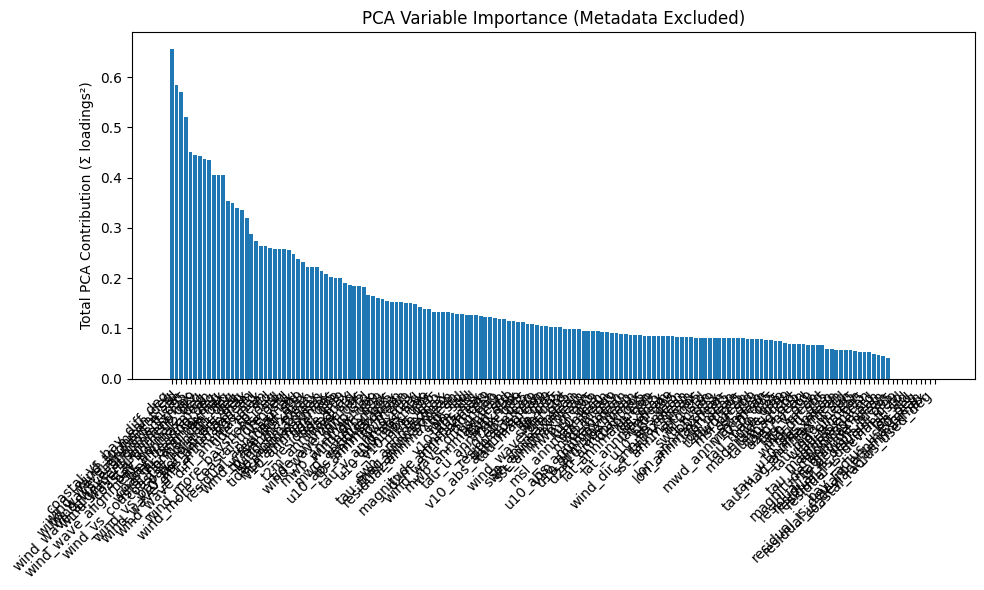

Variables used in PCA: 164
Retained PCs: 24
Cumulative variance explained: 0.950


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. DEFINE METADATA COLUMNS (EXCLUDED FROM PCA)
# --------------------------------------------------

metadata_cols = [c for c in metadata_cols if c in stats_df.columns]

# --------------------------------------------------
# 2. SELECT PCA VARIABLES ONLY
# --------------------------------------------------

pca_df = numeric_df.drop(columns=metadata_cols)

# Keep numeric variables only
pca_df = pca_df.select_dtypes(include=[np.number])

# Drop rows with missing values
pca_df = pca_df.dropna(axis=0)

# --------------------------------------------------
# 3. STANDARDIZE
# --------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

# --------------------------------------------------
# 4. FIT FULL PCA
# --------------------------------------------------

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# --------------------------------------------------
# 5. EXPLAINED VARIANCE TABLE
# --------------------------------------------------

explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(
            pca_full.explained_variance_ratio_
        ),
    }
)

# --------------------------------------------------
# 6. SELECT COMPONENTS (95% VARIANCE)
# --------------------------------------------------

n_components = int(
    explained_variance.loc[
        explained_variance["cumulative_explained_variance"] >= 0.95,
        "component",
    ].iloc[0]
)

# --------------------------------------------------
# 7. REFIT PCA WITH REDUCED DIMENSION
# --------------------------------------------------

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# --------------------------------------------------
# 8. PCA SCORES
# --------------------------------------------------

pca_columns = [f"PC{i+1}" for i in range(n_components)]
pca_scores_df = pd.DataFrame(
    X_pca,
    columns=pca_columns,
    index=pca_df.index,
)

# --------------------------------------------------
# 9. LOADINGS
# --------------------------------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_df.columns,
    columns=pca_columns,
)

# --------------------------------------------------
# 10. VARIABLE IMPORTANCE (Σ loadings²)
# --------------------------------------------------

variable_importance = (loadings ** 2).sum(axis=1)
variable_importance = variable_importance.sort_values(ascending=False)

# --------------------------------------------------
# 11. PLOT: MOST → LEAST IMPORTANT VARIABLES
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.bar(variable_importance.index, variable_importance.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total PCA Contribution (Σ loadings²)")
plt.title("PCA Variable Importance (Metadata Excluded)")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12. OPTIONAL: MERGE METADATA BACK
# --------------------------------------------------

final_pca_df = pd.concat(
    [
        numeric_df.loc[pca_scores_df.index, metadata_cols],
        pca_scores_df,
    ],
    axis=1,
)

# --------------------------------------------------
# 13. SUMMARY
# --------------------------------------------------

print(f"Variables used in PCA: {pca_df.shape[1]}")
print(f"Retained PCs: {n_components}")
print(
    f"Cumulative variance explained: "
    f"{explained_variance.loc[n_components-1, 'cumulative_explained_variance']:.3f}"
)


In [17]:
selected_vars = variable_importance.cumsum()
selected_vars = selected_vars[selected_vars <= 0.4 * selected_vars.iloc[-1]].index

In [18]:
hoi = selected_vars.to_list()
hoi.append("station")
selected_df = numeric_df[hoi]

In [20]:
selected_df

,coastal_vs_bay_diff_deg,wind_to_mean_deg,wind_wave_alignment_std,wind_wave_alignment_mean,wind_wave_alignment_q95,wind_wave_alignment_annmaxmax,wind_wave_alignment_q99,coastal_normal2_deg,bay_normal2_deg,wind_wave_alignment_annmaxmean,...,wind_vs_bay_normal_diff_deg,v10_abs_annmaxmax,wind_wave_diff_annmaxmean,tide_std,wind_wave_diff_annmaxmax,tide_mean,sp_std,wind_more_bayshore_deg,msl_std,station
0,0.016121,287.81160,NaN,NaN,NaN,NaN,NaN,147.672610,147.688731,NaN,...,-39.877116,20.684235,NaN,1.474239,NaN,-0.332307,1173.4281,50.122884,1175.2799,1
1,3.422662,285.32278,NaN,NaN,NaN,NaN,NaN,147.673516,151.096178,NaN,...,-45.773394,20.684235,NaN,1.457302,NaN,-0.336268,1169.6245,44.226606,1171.4858,2
2,0.016121,286.94376,NaN,NaN,NaN,NaN,NaN,147.672625,147.688746,NaN,...,-40.744990,20.684235,NaN,1.458467,NaN,-0.355250,1194.3428,49.255010,1196.4369,3
3,0.093866,324.85440,0.709762,-0.018946,0.982672,0.999971,0.999566,147.900559,147.994424,0.780945,...,-3.140024,17.261490,201.81592,1.324590,258.16098,-0.519457,1123.1482,86.859976,1123.3870,4
4,0.581781,341.98077,0.710379,-0.047405,0.954486,0.999954,0.998233,268.548052,267.966271,0.714748,...,74.014503,17.875671,189.02953,1.194291,290.25040,-0.274920,1209.1418,-15.985497,1209.4318,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,1.535953,282.07470,NaN,NaN,NaN,NaN,NaN,267.028509,268.564462,NaN,...,13.510245,13.684860,NaN,0.106061,NaN,-0.021565,1180.0630,-76.489755,1182.9618,574
275,0.008070,321.24335,NaN,NaN,NaN,NaN,NaN,76.737492,76.729422,NaN,...,64.513925,13.931763,NaN,0.145452,NaN,-0.026987,1206.9294,154.513925,1212.4583,575
276,0.007318,313.96740,0.701899,-0.002779,0.974212,0.999922,0.996493,180.004376,180.011694,0.845561,...,-46.044287,12.840744,190.15865,0.074902,297.91720,-0.033994,1098.5393,43.955713,1101.8021,576
277,1.537485,280.40604,NaN,NaN,NaN,NaN,NaN,267.026299,268.563784,NaN,...,11.842252,13.868332,NaN,0.091263,NaN,-0.044551,1099.3749,-78.157748,1102.3539,577


In [21]:
selected_df.to_csv("AVERAGE_Station_pca_variables.csv")